In [3]:
!pip  install  pandas
import pandas as pd
!pip  install  numpy
import numpy as np
!pip  install  matplotlib
import matplotlib.pyplot as plt
!pip  install  seaborn
import seaborn as sns

In [4]:
df = pd.read_csv("/content/Autism Spectrum Disorder Screening Data for Toddlers in Saudi Arabia Data Set.csv")
print(df.head())

print(df.shape)

print(df.dtypes)

print(df.isnull().sum())

   A10  A9  A8  A7  A6  A5  A4  A3  A2  A1            Region  \
0    0   0   1   1   1   0   0   0   0   0   Makkah Province   
1    0   0   1   0   0   1   0   1   0   0   Makkah Province   
2    0   0   0   1   0   0   0   0   0   0   Makkah Province   
3    0   0   0   0   0   0   0   0   0   0   Makkah Province   
4    0   0   0   0   0   0   0   0   0   0  Eastern Province   

  Family member with ASD history Who is completing the test  Age  Gender  \
0                             No              Family member   32  Female   
1                             No              Family member   30  Female   
2                             No              Family member   36    Male   
3                            Yes              Family member   36  Female   
4                             No              Family member   36  Female   

   Screening Score  Class  
0                3      0  
1                3      0  
2                1      0  
3                0      0  
4                0

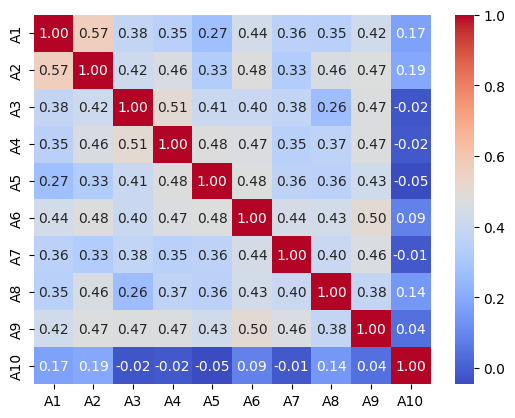

Class         0         1
A1     0.181818  0.747801
A2     0.042424  0.703812
A3     0.121212  0.700880
A4     0.121212  0.721408
A5     0.169697  0.747801
A6     0.060606  0.785924
A7     0.175758  0.736070
A8     0.169697  0.771261
A9     0.072727  0.771261
A10    0.484848  0.686217


In [5]:
a_cols = ['A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7', 'A8', 'A9', 'A10']


corr = df[a_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")


plt.show()
ratios = df.groupby('Class')[a_cols].mean()


print(ratios.T)

In [6]:
print(df.columns)

Index(['A10', 'A9', 'A8', 'A7', 'A6', 'A5', 'A4', 'A3', 'A2', 'A1', 'Region',
       'Family member with ASD history', 'Who is completing the test', 'Age',
       'Gender', 'Screening Score', 'Class'],
      dtype='object')


In [7]:
from sklearn.model_selection import train_test_split
X = df.drop('Class', axis=1)
y = df['Class']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (404, 16)
Testing Data: (102, 16)


In [8]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
import pandas as pd

X_train_all = X_train.drop('Screening Score', axis=1)
X_test_all = X_test.drop('Screening Score', axis=1)

X_train_all = pd.get_dummies(X_train_all)
X_test_all = pd.get_dummies(X_test_all)

X_train_all, X_test_all = X_train_all.align(X_test_all, join='left', axis=1, fill_value=0)

rf = RandomForestClassifier(random_state=42, class_weight='balanced')
rf.fit(X_train_all, y_train)
y_pred = rf.predict(X_test_all)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.94      0.97        33
           1       0.97      1.00      0.99        69

    accuracy                           0.98       102
   macro avg       0.99      0.97      0.98       102
weighted avg       0.98      0.98      0.98       102



In [9]:
print(y_pred[:15])
data = {'Feature': X_train_all.columns, 'Importance': rf.feature_importances_}
df_imp = pd.DataFrame(data).sort_values(by='Importance', ascending=False)
print(df_imp.head(10))

[1 1 0 0 0 1 1 1 1 1 0 1 0 1 1]
   Feature  Importance
1       A9    0.166679
8       A2    0.146538
4       A6    0.144425
3       A7    0.084156
7       A3    0.072930
2       A8    0.070803
6       A4    0.069520
5       A5    0.060918
9       A1    0.041552
10     Age    0.039144


In [ ]:
for i, p in enumerate(y_pred[:10], 1):
    status = "ASD" if p == 1 else "Normal"
    print(f"Child {i}: {status}")

Child 1: ASD
Child 2: ASD
Child 3: Normal
Child 4: Normal
Child 5: Normal


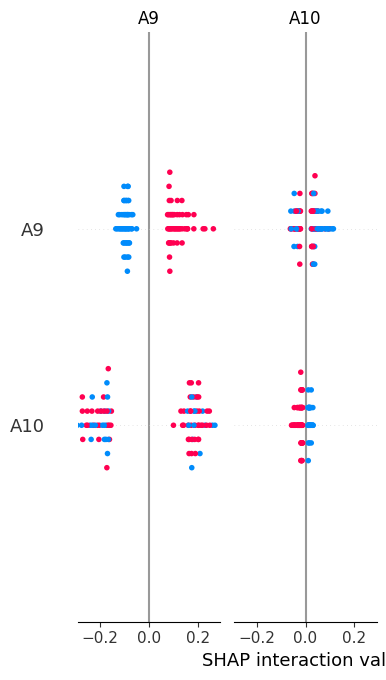

In [14]:
import shap
import matplotlib.pyplot as plt

# 1. التأكد من إنشاء المتغيرات وتحضير البيانات بالشكل الصحيح للموديل الشامل
X_train_encoded = pd.get_dummies(X_train.drop('Screening Score', axis=1))
X_test_encoded = pd.get_dummies(X_test.drop('Screening Score', axis=1))
X_train_encoded, X_test_encoded = X_train_encoded.align(X_test_encoded, join='left', axis=1, fill_value=0)

# 2. إنشاء وتدريب النموذج من جديد لضمان مطابقة الأعمدة تماماً
rf_model = RandomForestClassifier(random_state=42, class_weight='balanced')
rf_model.fit(X_train_encoded, y_train)

# 3. حساب قيم SHAP وتوليد الرسم البياني للتفسير
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_test_encoded)

# التعامل المرن مع شكل مخرجات SHAP سواء كانت قائمة أو مصفوفة
if isinstance(shap_values, list):
    shap.summary_plot(shap_values[1], X_test_encoded, plot_type='bar')
else:
    shap.summary_plot(shap_values, X_test_encoded, plot_type='bar')

plt.show()